In [1]:
import os
import numpy as np
from scipy.fftpack import fft2
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib import font_manager
from pathlib import Path
from prf_expect.utils.beh import calculate_visual_angle
from prf_expect.utils import io
from prf_expect.utils.viz import cm_to_inch

In [2]:
cwd = os.getcwd()
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc('pdf', fonttype=42, use14corefonts=False)
rc('axes', linewidth=0.5)
rc('font',**{'family':'Arial'})
rc('text', usetex=False)
rc('xtick', labelsize=6)
rc('ytick', labelsize=6)
rc('axes', labelsize=6)
rc('legend', fontsize=6)

plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 1
plt.rcParams['ytick.minor.size'] = 1

In [3]:
figure_result_dir = Path(cwd).parent / "figures"
bar_image_path = Path("./pRFbar_Screenshots275.png")
bar_image = plt.imread(bar_image_path)

In [4]:
# Orientation spectrum in 180° (orientation) space
# Uses fftshift so angles are measured around the DC-centered spectrum, then folds to [-90, 90].
def orientation_spectrum(image_patch, nr_bin):
    # 2D FFT and shift DC to center
    F = fft2(image_patch - np.mean(image_patch))
    P = np.abs(np.fft.fftshift(F))**2  # power spectrum, DC at center
    
    # Polar coordinates (frequency, orientation)
    rows, cols = P.shape
    cy, cx = rows//2, cols//2
    y, x = np.ogrid[:rows, :cols]
    radius = np.sqrt((x-cx)**2 + (y-cy)**2)
    angle = np.arctan2(y-cy, x-cx) * 180/np.pi  # degrees, range [-180, 180]

    # Fold to orientation space: [-90, 90]
    angle_orient = (angle + 90) % 180 - 90
    
    # Bin by orientation (ignore DC/radius=0)
    orient_bins = np.linspace(-90, 90, nr_bin)
    orient_energy = []
    for i in range(len(orient_bins)-1):
        mask = (angle_orient >= orient_bins[i]) & (angle_orient < orient_bins[i+1]) # (radius > 5)
        orient_energy.append(np.sum(P[mask]))
    
    return np.array(orient_energy)


<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/var/folders/1x/nhszthp519l9hrq_yddm9yhr0000gn/T/ipykernel_26859/3645959280.py:57: SyntaxWarning: invalid escape sequence '\s'
  axes[0, idx].set_title(f"$\sigma$ = {sigma_deg:g}°", fontsize=6)


Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


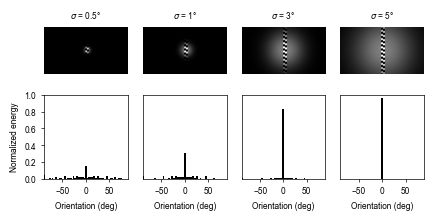

In [5]:
# Compare orientation energy across pRF sizes (degrees) using Gaussian windows centered on image
# Pulls monitor geometry from settings to convert deg → px.
import numpy as np
import matplotlib.pyplot as plt

# Monitor geometry and deg→px conversion
settings = io.load_settings()
screen_size_cm = settings["monitor"]["screen_size_cm"]
screen_size_pix = settings["monitor"]["screen_size_pix"]
distance_to_screen = settings["monitor"]["screen_distance_cm"]
screen_height_deg = calculate_visual_angle(screen_size_cm[1], distance_to_screen)
pixels_per_deg = screen_size_pix[1] / screen_height_deg

# Choose pRF sigmas in degrees (tweak as needed)
prf_sizes_deg = [0.5, 1.0, 3.0, 5.0]
prf_sizes_px = [sigma_deg * pixels_per_deg for sigma_deg in prf_sizes_deg]

# Grayscale bar image
if bar_image.ndim == 3:
    gray = bar_image.mean(axis=2)
else:
    gray = bar_image

# make it binary, make white and black into 1, and gray into 0.5
gray_binary = np.where(gray != np.median(gray), 1, 0)

h, w = gray.shape
cy, cx = h // 2, w // 2 + 30

# Precompute orientation bin centers for plotting (matches orientation_spectrum bins)
nr_bins = 180
orient_edges = np.linspace(-90, 90, nr_bins)
orient_centers = (orient_edges[:-1] + orient_edges[1:]) / 2

energy_by_size = []
windowed_samples = []

y, x = np.ogrid[:h, :w]
for sigma_deg, sigma_px in zip(prf_sizes_deg, prf_sizes_px):
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray_binary * mask
    windowed_original = gray * mask
    windowed_samples.append(windowed_original)

    energy = orientation_spectrum(windowed, nr_bins)
    energy_by_size.append(energy / energy.sum())  # normalize for comparison

# Plot windowed images and orientation spectra
fig, axes = plt.subplots(
    2,
    len(prf_sizes_px),
    figsize=cm_to_inch(11.4, 6),
    gridspec_kw={"height_ratios": [1, 1]},
)
for idx, (sigma_deg, sigma_px) in enumerate(zip(prf_sizes_deg, prf_sizes_px)):
    axes[0, idx].imshow(windowed_samples[idx], cmap="gray")
    axes[0, idx].set_title(f"$\sigma$ = {sigma_deg:g}°", fontsize=6)
    axes[0, idx].axis("off")

    # axes[1, idx].plot(orient_centers, energy_by_size[idx], linewidth=0.5, color="k")
    # bar plot of energy by orientation bin
    axes[1, idx].bar(orient_centers, energy_by_size[idx], width=4, color="k", edgecolor="none")

    axes[1, idx].set_xlim(-90, 90)
    axes[1, idx].set_ylim(0, 1)
    axes[1, idx].set_xlabel("Orientation (deg)")
    axes[1, idx].set_box_aspect(1)  # make second-row axes roughly square like the images
    if idx==0:
        axes[1, idx].set_ylabel("Normalized energy")
    if idx>0:
        axes[1, idx].set_yticks([])

plt.tight_layout()
fig.savefig(figure_result_dir / f"broadband_orientation_energy.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"broadband_orientation_energy.png", dpi=600, bbox_inches='tight')

In [6]:
# Fraction of orientation energy within ±10° of the bar orientation
# 1) Estimate bar orientation from the full (unwindowed) binary image.
bar_energy = orientation_spectrum(gray_binary, nr_bins)
bar_energy = bar_energy / (bar_energy.sum() + 1e-12)
bar_orientation_deg = orient_centers[np.argmax(bar_energy)]

# 2) Compute orientation distance in 180° orientation space.
def orientation_distance_deg(theta, theta0):
    return np.abs((theta - theta0 + 90) % 180 - 90)

within_10deg = orientation_distance_deg(orient_centers, bar_orientation_deg) <= 10

# 3) Fraction within ±10° for each pRF size.
fraction_within_10deg = [
    float(np.sum(energy[within_10deg])) for energy in energy_by_size
]

print(f"Estimated bar orientation: {bar_orientation_deg:.1f}°")
print("Fraction of orientation energy within ±10° of bar orientation")
for sigma_deg, frac in zip(prf_sizes_deg, fraction_within_10deg):
    print(f"  sigma={sigma_deg:>4.1f}°: {frac:.4f}")

# Optional compact table for downstream use.
import pandas as pd
fraction_df = pd.DataFrame({
    "prf_sigma_deg": prf_sizes_deg,
    "fraction_within_pm10deg": fraction_within_10deg,
})
fraction_df

Estimated bar orientation: 0.0°
Fraction of orientation energy within ±10° of bar orientation
  sigma= 0.5°: 0.3526
  sigma= 1.0°: 0.5720
  sigma= 3.0°: 0.9138
  sigma= 5.0°: 0.9828


,prf_sigma_deg,fraction_within_pm10deg
0,0.5,0.352555
1,1.0,0.572027
2,3.0,0.913755
3,5.0,0.982775


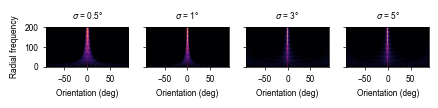

In [7]:
# Orientation–frequency 2D histogram (orientation × radial frequency) for each pRF size
# Clip low/DC and very high frequencies, reduce bin count, and log-scale power to spread dynamic range.
min_r = 0
max_r = 200
freq_bins = np.linspace(min_r, max_r, 30)
orient_bins = np.linspace(-90, 90, nr_bins)
energy2d = []

# Recompute windowed binary images (centered Gaussian masks per pRF size)
y, x = np.ogrid[:h, :w]
for sigma_px in prf_sizes_px:
    mask = np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma_px ** 2))
    windowed = gray_binary * mask

    # FFT power spectrum in polar coords (radius, orientation)
    F = fft2(windowed - np.mean(windowed))
    P = np.abs(np.fft.fftshift(F)) ** 2
    rows, cols = P.shape
    cy_f, cx_f = rows // 2, cols // 2
    yy, xx = np.ogrid[:rows, :cols]
    radius = np.sqrt((xx - cx_f) ** 2 + (yy - cy_f) ** 2)
    angle = np.arctan2(yy - cy_f, xx - cx_f) * 180 / np.pi
    angle_orient = (angle + 90) % 180 - 90

    valid = (radius >= min_r) & (radius <= max_r)
    hist2d, _, _ = np.histogram2d(
        angle_orient[valid],
        radius[valid],
        bins=[orient_bins, freq_bins],
        weights=np.log1p(P)[valid],
    )
    # hist2d /= hist2d.sum() + 1e-12
    energy2d.append(hist2d)

# Shared color scale across subplots
vmin = 0.0
vmax = max(h.max() for h in energy2d)

# Plot 2D histograms
fig, axes = plt.subplots(
    1,
    len(prf_sizes_px),
    figsize=cm_to_inch(11.4, 3),
    sharey=True,
)
for idx, hist2d in enumerate(energy2d):
    im = axes[idx].imshow(
        hist2d.T,
        extent=(orient_bins[0], orient_bins[-1], freq_bins[0], freq_bins[-1]),
        aspect="auto",
        origin="lower",
        cmap="magma",
        vmin=vmin,
        vmax=vmax,
    )
    axes[idx].set_title(f"$\\sigma$ = {prf_sizes_deg[idx]:g}°", fontsize=6)
    axes[idx].set_xlabel("Orientation (deg)")
    axes[idx].set_xlim(-90, 90)
    if idx == 0:
        axes[idx].set_ylabel("Radial frequency")

# cbar = fig.colorbar(
#     im,
#     ax=axes.ravel().tolist(),
#     fraction=0.035,
#     pad=0.04,
#     location="right",
# )
# cbar.set_label("Normalized energy (log-weighted)")
fig.tight_layout()
fig.savefig(figure_result_dir / f"broadband_orientation_frequency_energy.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"broadband_orientation_frequency_energy.png", dpi=600, bbox_inches='tight')